In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import plotly.express as px

In [2]:
df = pd.read_csv("data/laptop_data.csv")

In [3]:
df.sample(4)

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
650,650,Asus,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 6820HK 2.7GHz,32GB,512GB SSD,Nvidia GeForce GTX 1080,Windows 10,3.8kg,149130.72
279,279,Lenovo,Notebook,17.3,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,8GB,2TB HDD,Nvidia GeForce MX150,No OS,2.8kg,45234.72
414,414,Asus,2 in 1 Convertible,13.3,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.27kg,49443.84
864,864,Dell,Ultrabook,13.3,Quad HD+ / Touchscreen 3200x1800,Intel Core i7 7660U 2.5GHz,16GB,512GB SSD,Intel Iris Plus Graphics 640,Windows 10,1.29kg,119347.20


In [4]:
df.isnull().sum()

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['Company'].unique()

array(['Apple', 'HP', 'Acer', 'Asus', 'Dell', 'Lenovo', 'Chuwi', 'MSI',
       'Microsoft', 'Toshiba', 'Huawei', 'Xiaomi', 'Vero', 'Razer',
       'Mediacom', 'Samsung', 'Google', 'Fujitsu', 'LG'], dtype=object)

In [7]:
df['TypeName'].unique()

array(['Ultrabook', 'Notebook', 'Netbook', 'Gaming', '2 in 1 Convertible',
       'Workstation'], dtype=object)

In [8]:
df['Ram'].unique()

array(['8GB', '16GB', '4GB', '2GB', '12GB', '6GB', '32GB', '24GB', '64GB'],
      dtype=object)

In [9]:
df['OpSys'].unique()

array(['macOS', 'No OS', 'Windows 10', 'Mac OS X', 'Linux', 'Android',
       'Windows 10 S', 'Chrome OS', 'Windows 7'], dtype=object)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [11]:
#remouve unwanted index column 
#no missing value and no any duplicated values
#remuve GB fro m the Ram column   ,  and also remove kg from Weight column 
# use onehotencoder on opSys , TypeName , company , 

In [12]:
df.drop(columns=["Unnamed: 0"] , inplace=True)

In [13]:
df.sample(3)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
643,Asus,Gaming,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,1TB HDD,Nvidia GeForce GTX 1050 Ti,No OS,2.5kg,62284.3200
1245,Asus,Gaming,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1050 Ti,Windows 10,2.5kg,85248.0000
42,Asus,Notebook,15.6,1366x768,Intel Core i5 7200U 2.5GHz,8GB,1TB HDD,Nvidia GeForce 940MX,Linux,2.3kg,27864.9072


In [14]:
df['Ram'] = df['Ram'].str.replace('GB' , '').astype(int)
df['Weight'] = df['Weight'].str.split('kg').str[0].astype(float)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int64  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float64
 10  Price             1303 non-null   float64
dtypes: float64(3), int64(1), object(7)
memory usage: 112.1+ KB


In [16]:
df.sample(3)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
216,Lenovo,Notebook,17.3,1600x900,Intel Core i5 7200U 2.5GHz,8,1TB HDD,Nvidia GeForce GTX 940MX,No OS,2.80,31381.92
138,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4,1TB HDD,Nvidia GeForce 920MX,No OS,2.20,26586.72
985,Dell,Notebook,15.6,1366x768,Intel Core i5 7200U 2.5GHz,4,500GB HDD,AMD Radeon R5 M430,Windows 10,2.25,31914.72


## EDA 

Text(0, 0.5, 'count')

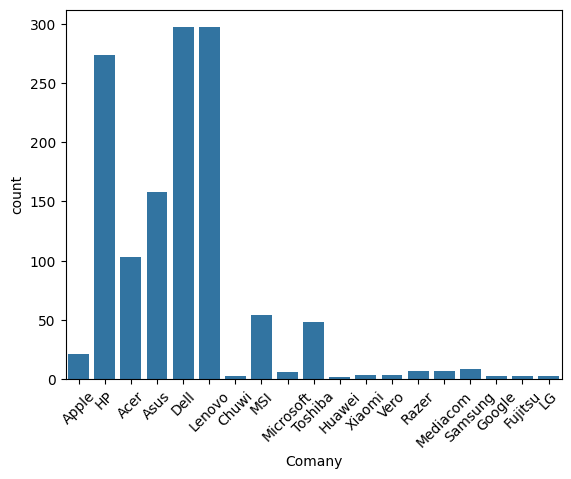

In [17]:
sns.countplot( x= df['Company'] )
plt.xticks(rotation=45)
plt.xlabel("Comany")
plt.ylabel("count")

Text(0, 0.5, 'count')

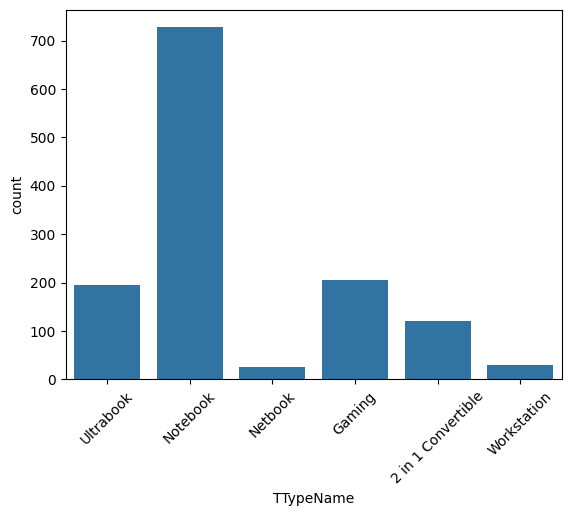

In [18]:
sns.countplot( x= df['TypeName'] )
plt.xticks(rotation=45)
plt.xlabel("TTypeName")
plt.ylabel("count")

<Axes: xlabel='Price', ylabel='Company'>

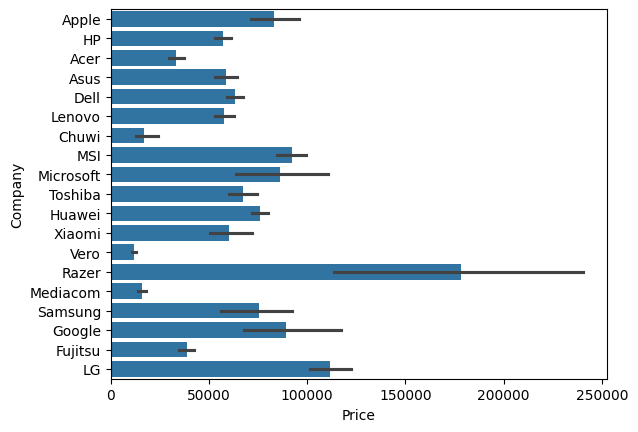

In [19]:
sns.barplot(y= df['Company'] , x = df['Price'])

Text(0, 0.5, 'price')

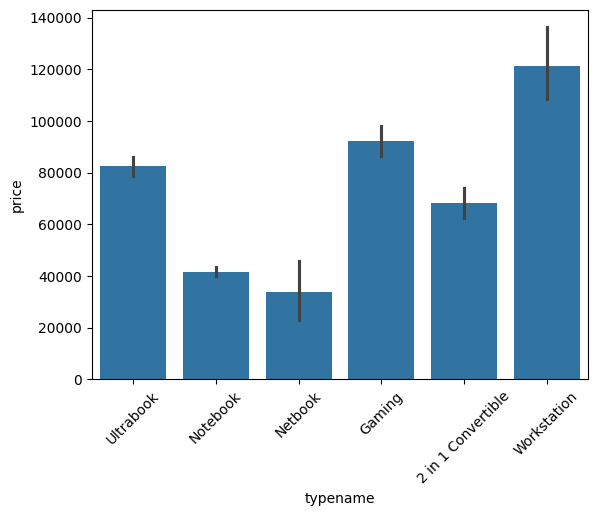

In [20]:
sns.barplot(x= df['TypeName'] , y= df['Price'])
plt.xticks(rotation= 45)
plt.xlabel("typename")
plt.ylabel("price")

C:\Users\yashs\AppData\Local\Temp\ipykernel_5352\863594587.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Ram'])


<Axes: xlabel='Ram', ylabel='Density'>

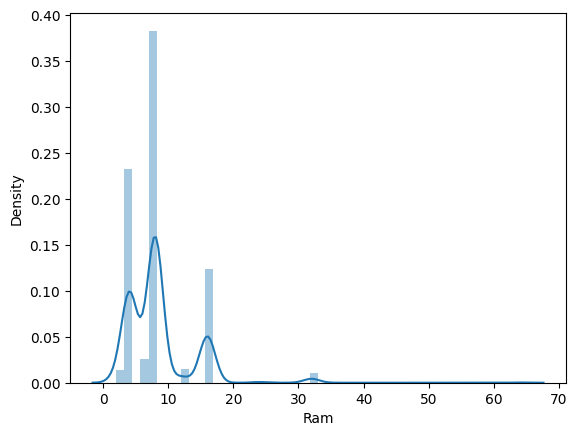

In [21]:
sns.distplot(df['Ram'])

C:\Users\yashs\AppData\Local\Temp\ipykernel_5352\1439577752.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Inches'])


<Axes: xlabel='Inches', ylabel='Density'>

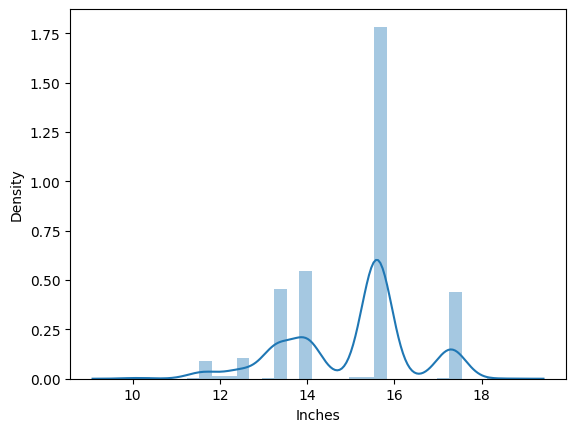

In [22]:
sns.distplot(df['Inches'])

Text(0.5, 1.0, 'ram  on QQ plot')

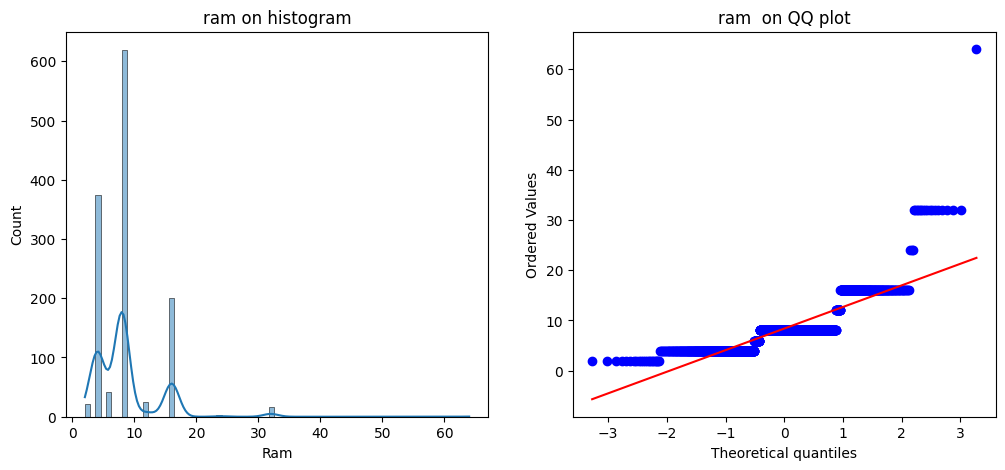

In [23]:
plt.figure(figsize=(12,5))
plt.subplot(121)
sns.histplot(df["Ram"] , kde=True)
plt.title("ram on histogram")

plt.subplot(122)
stats.probplot(df["Ram"]  , plot=plt)
plt.title("ram  on QQ plot" )

Text(0.5, 1.0, 'inches on QQ plot')

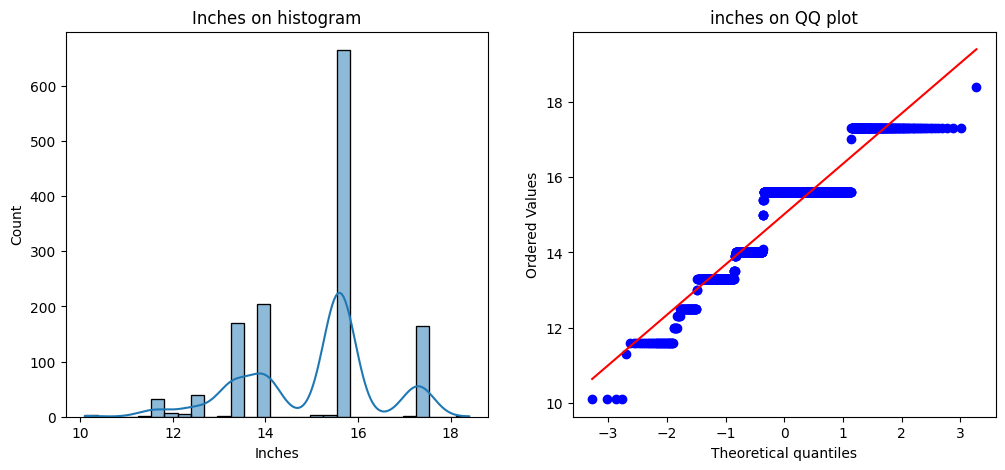

In [24]:
plt.figure(figsize=(12,5))
plt.subplot(121)
sns.histplot(df["Inches"] , kde=True)
plt.title("Inches on histogram")

plt.subplot(122)
stats.probplot(df["Inches"]  , plot=plt)
plt.title("inches on QQ plot" )

Text(0.5, 1.0, 'weight  on QQ plot')

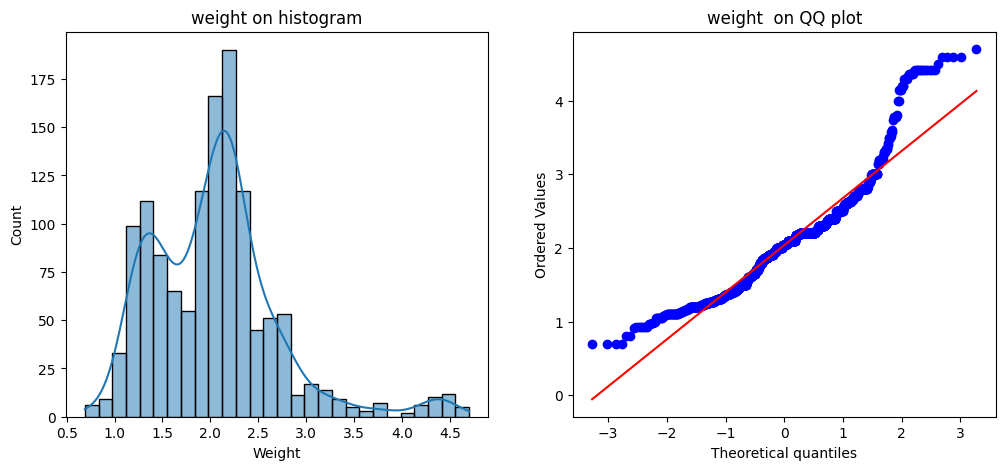

In [25]:
plt.figure(figsize=(12,5))
plt.subplot(121)
sns.histplot(df["Weight"] , kde=True)
plt.title("weight on histogram")

plt.subplot(122)
stats.probplot(df["Weight"]  , plot=plt)
plt.title("weight  on QQ plot" )

In [26]:
df.columns

Index(['Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram',
       'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='object')

In [27]:
df['ScreenResolution'].unique()

array(['IPS Panel Retina Display 2560x1600', '1440x900',
       'Full HD 1920x1080', 'IPS Panel Retina Display 2880x1800',
       '1366x768', 'IPS Panel Full HD 1920x1080',
       'IPS Panel Retina Display 2304x1440',
       'IPS Panel Full HD / Touchscreen 1920x1080',
       'Full HD / Touchscreen 1920x1080',
       'Touchscreen / Quad HD+ 3200x1800',
       'IPS Panel Touchscreen 1920x1200', 'Touchscreen 2256x1504',
       'Quad HD+ / Touchscreen 3200x1800', 'IPS Panel 1366x768',
       'IPS Panel 4K Ultra HD / Touchscreen 3840x2160',
       'IPS Panel Full HD 2160x1440',
       '4K Ultra HD / Touchscreen 3840x2160', 'Touchscreen 2560x1440',
       '1600x900', 'IPS Panel 4K Ultra HD 3840x2160',
       '4K Ultra HD 3840x2160', 'Touchscreen 1366x768',
       'IPS Panel Full HD 1366x768', 'IPS Panel 2560x1440',
       'IPS Panel Full HD 2560x1440',
       'IPS Panel Retina Display 2736x1824', 'Touchscreen 2400x1600',
       '2560x1440', 'IPS Panel Quad HD+ 2560x1440',
       'IPS Panel 

In [28]:
df['TouchScreen'] = df['ScreenResolution'].apply(lambda x : 1 if 'Touchscreen' in x else 0  )

In [29]:
df['IPS_Panel'] = df['ScreenResolution'].apply(lambda x : 1 if 'IPS Panel' in x else 0 )

In [30]:
new  = df['ScreenResolution'].str.split('x' , n= 1 , expand=True )
df['x_Resolution'] = new[0]
df['y_Resolution'] = new[1]

In [31]:
df.sample(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS_Panel,x_Resolution,y_Resolution
470,HP,2 in 1 Convertible,13.3,IPS Panel 4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 8550U 1.8GHz,8,512GB SSD,Intel UHD Graphics 620,Windows 10,1.29,106506.7200,1,1,IPS Panel 4K Ultra HD / Touchscreen 3840,2160
167,Dell,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1050,Windows 10,2.56,56502.9072,0,0,Full HD 1920,1080


In [32]:
df['x_Resolution']= df['x_Resolution'].str.extract('(\d+)')

In [33]:
df.head(4)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS_Panel,x_Resolution,y_Resolution
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int64  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float64
 10  Price             1303 non-null   float64
 11  TouchScreen       1303 non-null   int64  
 12  IPS_Panel         1303 non-null   int64  
 13  x_Resolution      1303 non-null   object 
 14  y_Resolution      1303 non-null   object 
dtypes: float64(3), int64(3), object(9)
memory usage: 152.8+ KB


In [35]:
df['x_Resolution']= df['x_Resolution'].astype(int)
df['y_Resolution']= df['y_Resolution'].astype(int)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int64  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float64
 10  Price             1303 non-null   float64
 11  TouchScreen       1303 non-null   int64  
 12  IPS_Panel         1303 non-null   int64  
 13  x_Resolution      1303 non-null   int64  
 14  y_Resolution      1303 non-null   int64  
dtypes: float64(3), int64(5), object(7)
memory usage: 152.8+ KB


In [37]:
# ppi = pixel per inches
# formula = sqrt(width**2 + height**2) / Inches

df["ppi"] = ((df['x_Resolution']**2 )+(df["y_Resolution"]**2))**0.5/df["Inches"]

In [38]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS_Panel,x_Resolution,y_Resolution,ppi
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600,226.983005
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900,127.677940
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080,141.211998
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800,220.534624
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600,226.983005


In [39]:
df.drop(columns=['x_Resolution', 'y_Resolution' , 'Inches' , 'ScreenResolution'],inplace=True)

In [40]:
df.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS_Panel,ppi
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005


In [41]:
df.corr(numeric_only=True)

,Ram,Weight,Price,TouchScreen,IPS_Panel,ppi
Ram,1.000000,0.383874,0.743007,0.116984,0.206623,0.186012
Weight,0.383874,1.000000,0.210370,-0.294620,0.016967,-0.449028
Price,0.743007,0.210370,1.000000,0.191226,0.252208,0.348331
TouchScreen,0.116984,-0.294620,0.191226,1.000000,0.150512,0.416460
IPS_Panel,0.206623,0.016967,0.252208,0.150512,1.000000,0.287694
ppi,0.186012,-0.449028,0.348331,0.416460,0.287694,1.000000


In [42]:
                                                                ## work with the Cpu column

In [43]:
list(df['Cpu'])[:20]

['Intel Core i5 2.3GHz',
 'Intel Core i5 1.8GHz',
 'Intel Core i5 7200U 2.5GHz',
 'Intel Core i7 2.7GHz',
 'Intel Core i5 3.1GHz',
 'AMD A9-Series 9420 3GHz',
 'Intel Core i7 2.2GHz',
 'Intel Core i5 1.8GHz',
 'Intel Core i7 8550U 1.8GHz',
 'Intel Core i5 8250U 1.6GHz',
 'Intel Core i5 7200U 2.5GHz',
 'Intel Core i3 6006U 2GHz',
 'Intel Core i7 2.8GHz',
 'Intel Core i3 6006U 2GHz',
 'Intel Core M m3 1.2GHz',
 'Intel Core i5 2.3GHz',
 'Intel Core i7 7500U 2.7GHz',
 'Intel Core i7 2.9GHz',
 'Intel Core i3 7100U 2.4GHz',
 'Intel Core i5 8250U 1.6GHz']

In [44]:
df['Cpu_Name'] = df['Cpu'].apply(lambda x:" ".join(x.split()[0:3]))

In [45]:
df.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS_Panel,ppi,Cpu_Name
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5


In [46]:
df["Cpu_Name"].unique()

array(['Intel Core i5', 'Intel Core i7', 'AMD A9-Series 9420',
       'Intel Core i3', 'Intel Core M', 'Intel Atom x5-Z8350',
       'AMD E-Series E2-9000e', 'Intel Atom x5-Z8300',
       'AMD E-Series E2-6110', 'AMD A6-Series 9220', 'Intel Celeron Dual',
       'AMD Ryzen 1700', 'Intel Pentium Quad', 'Intel Atom x5-Z8550',
       'AMD FX 9830P', 'AMD E-Series 6110', 'Intel Xeon E3-1505M',
       'AMD E-Series 9000e', 'AMD A10-Series A10-9620P',
       'AMD A6-Series A6-9220', 'AMD A10-Series 9600P',
       'AMD A8-Series 7410', 'AMD A12-Series 9720P', 'Intel Celeron Quad',
       'AMD Ryzen 1600', 'AMD A10-Series 9620P', 'AMD E-Series 7110',
       'AMD A9-Series A9-9420', 'Intel Xeon E3-1535M',
       'AMD E-Series E2-9000', 'AMD A6-Series 7310', 'Intel Atom Z8350',
       'Intel Pentium Dual', 'AMD A12-Series 9700P', 'AMD A4-Series 7210',
       'AMD FX 8800P', 'Intel Atom X5-Z8350', 'Samsung Cortex A72&A53',
       'AMD E-Series 9000', 'AMD A9-Series 9410'], dtype=object)

In [47]:
df['Cpu_Name'].value_counts()

Cpu_Name
Intel Core i7               527
Intel Core i5               423
Intel Core i3               136
Intel Celeron Dual           80
Intel Pentium Quad           27
Intel Core M                 19
AMD A9-Series 9420           12
Intel Celeron Quad            8
AMD A6-Series 9220            8
AMD A12-Series 9720P          7
Intel Atom x5-Z8350           5
AMD A8-Series 7410            4
Intel Atom x5-Z8550           4
Intel Pentium Dual            3
AMD A9-Series 9410            3
AMD Ryzen 1700                3
AMD A9-Series A9-9420         2
AMD A10-Series 9620P          2
Intel Atom X5-Z8350           2
AMD E-Series E2-9000e         2
Intel Xeon E3-1535M           2
Intel Xeon E3-1505M           2
AMD E-Series 7110             2
AMD A10-Series 9600P          2
AMD A6-Series A6-9220         2
AMD A10-Series A10-9620P      2
AMD Ryzen 1600                1
Intel Atom x5-Z8300           1
AMD E-Series E2-6110          1
AMD FX 9830P                  1
AMD E-Series E2-9000          1

In [48]:
# def feach_processor (text):
#     if text == "Intel Core i3" or  text == "Intel Core i5" or text == "Intel Core i7":
#         return text
#     else :
#         if text.split()[0] == "Intel":
#             return "other intel processor"
#         else:
#             return "AMD processor"
        

In [49]:
# df['Cpu brand'] = df['Cpu_Name'].apply(feach_processor)

In [50]:
df = df.drop(columns=['Cpu'])

<Axes: xlabel='Cpu_Name'>

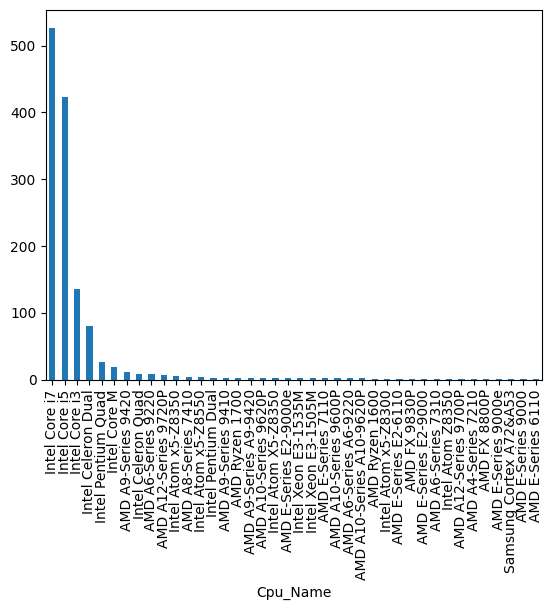

In [51]:
df['Cpu_Name'].value_counts().plot(kind='bar')

In [52]:
df.sample(5)

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS_Panel,ppi,Cpu_Name
1242,Acer,Notebook,4,500GB HDD,Intel HD Graphics 520,Linux,2.40,19276.7040,0,0,100.454670,Intel Core i3
348,Asus,2 in 1 Convertible,4,32GB Flash Storage,Intel HD Graphics 500,Windows 10,1.50,19980.0000,1,0,135.094211,Intel Celeron Dual
354,Toshiba,Notebook,16,512GB SSD,Nvidia GeForce 930M,Windows 10,2.40,74751.8400,0,1,141.211998,Intel Core i7
240,Lenovo,Notebook,8,128GB SSD,Intel HD Graphics 520,Windows 10,2.20,31381.9200,0,0,100.454670,Intel Core i3
835,Dell,Gaming,16,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,3.21,147832.2864,0,0,141.211998,Intel Core i7


<Axes: xlabel='Ram'>

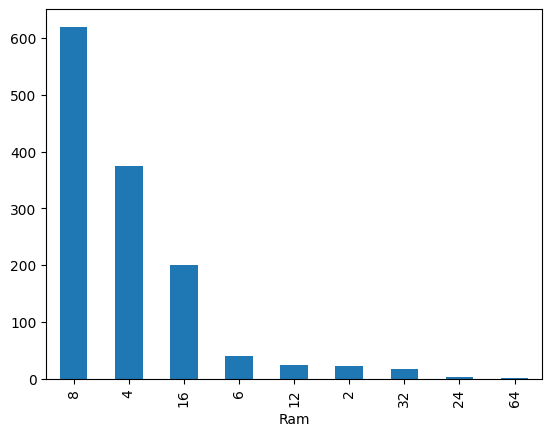

In [53]:
df["Ram"].value_counts().plot(kind = 'bar')

Text(0, 0.5, 'price')

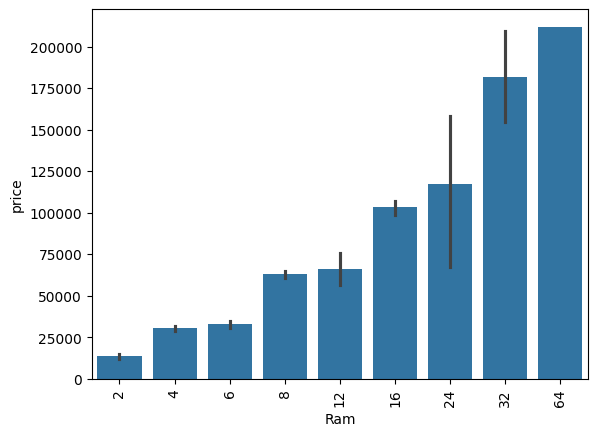

In [54]:
sns.barplot(x=df['Ram'],y=df['Price'])
plt.xticks(rotation='vertical')
plt.xlabel("Ram")
plt.ylabel("price")

In [55]:
                                                        ## work with the Memory column 

In [56]:
df["Memory"].value_counts()

Memory
256GB SSD                        412
1TB HDD                          223
500GB HDD                        132
512GB SSD                        118
128GB SSD +  1TB HDD              94
128GB SSD                         76
256GB SSD +  1TB HDD              73
32GB Flash Storage                38
2TB HDD                           16
64GB Flash Storage                15
512GB SSD +  1TB HDD              14
1TB SSD                           14
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
512GB SSD +  2TB HDD               3
16GB SSD                           3
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB SSD +  256GB SSD         

In [57]:
df[df['Memory']== "256GB SSD +  256GB SSD"]

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS_Panel,ppi,Cpu_Name
28,Dell,Ultrabook,8,256GB SSD + 256GB SSD,Intel UHD Graphics 620,Windows 10,1.88,69157.44,0,0,141.211998,Intel Core i7
901,Asus,Gaming,32,256GB SSD + 256GB SSD,Nvidia GeForce GTX 980M,Windows 10,3.58,68145.12,0,1,127.335675,Intel Core i7


In [58]:
df['Memory'] = df['Memory'].astype(str).replace('\.0', '', regex=True)

In [59]:
df["Memory"] = df["Memory"].str.replace('GB', '')
df["Memory"] = df["Memory"].str.replace('TB', '000')

In [60]:
new = df["Memory"].str.split("+", n = 1, expand = True)

In [61]:
new

,0,1
0,128 SSD,None
1,128 Flash Storage,None
2,256 SSD,None
3,512 SSD,None
4,256 SSD,None
...,...,...
1298,128 SSD,None
1299,512 SSD,None
1300,64 Flash Storage,None
1301,1000 HDD,None


In [62]:
df["first"]= new[0]
df["first"]=df["first"].str.strip()
df["second"]= new[1]

In [63]:
df["Layer1HDD"] = df["first"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer1SSD"] = df["first"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer1Hybrid"] = df["first"].apply(lambda x: 1 if "Hybrid" in x else 0)
df["Layer1Flash_Storage"] = df["first"].apply(lambda x: 1 if "Flash Storage" in x else 0)


In [64]:
df["first"] = df["first"].str.extract(r'(\d+)').astype(int)

In [65]:
df["second"].fillna("0", inplace = True)

C:\Users\yashs\AppData\Local\Temp\ipykernel_5352\3637126284.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["second"].fillna("0", inplace = True)


In [66]:
df["Layer2HDD"] = df["second"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer2SSD"] = df["second"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer2Hybrid"] = df["second"].apply(lambda x: 1 if "Hybrid" in x else 0)
df["Layer2Flash_Storage"] = df["second"].apply(lambda x: 1 if "Flash Storage" in x else 0)


In [67]:
df["second"] = df["second"].str.extract(r'(\d+)').astype(int)

In [68]:
df["first"] = df["first"].astype(int)
df["second"] = df["second"].astype(int)

In [69]:
df["HDD"]=(df["first"]*df["Layer1HDD"]+df["second"]*df["Layer2HDD"])
df["SSD"]=(df["first"]*df["Layer1SSD"]+df["second"]*df["Layer2SSD"])
df["Hybrid"]=(df["first"]*df["Layer1Hybrid"]+df["second"]*df["Layer2Hybrid"])
df["Flash_Storage"]=(df["first"]*df["Layer1Flash_Storage"]+df["second"]*df["Layer2Flash_Storage"])

In [70]:
df.drop(columns=['first', 'second', 'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid',
       'Layer1Flash_Storage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid',
       'Layer2Flash_Storage'],inplace=True)

In [71]:
df.drop(columns=['Memory'], inplace=True)

In [72]:
df.sample(5)

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,TouchScreen,IPS_Panel,ppi,Cpu_Name,HDD,SSD,Hybrid,Flash_Storage
1222,HP,Notebook,6,AMD Radeon 530,Windows 10,2.10,28185.12,0,0,141.211998,AMD A12-Series 9720P,1000,0,0,0
830,Razer,Gaming,32,Nvidia GeForce GTX 1080,Windows 10,3.49,292986.72,1,0,124.855705,Intel Core i7,0,512,0,0
912,Lenovo,Notebook,6,Nvidia GeForce 940MX,Windows 10,2.20,42037.92,0,0,141.211998,Intel Core i7,0,256,0,0
330,MSI,Gaming,8,Nvidia GeForce GTX 1050 Ti,Windows 10,2.70,63882.72,0,0,127.335675,Intel Core i7,1000,256,0,0
95,Acer,2 in 1 Convertible,8,Intel UHD Graphics 620,Windows 10,1.50,45128.16,1,1,165.632118,Intel Core i5,0,256,0,0


In [73]:
df.sample()

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,TouchScreen,IPS_Panel,ppi,Cpu_Name,HDD,SSD,Hybrid,Flash_Storage
596,Lenovo,2 in 1 Convertible,8,Intel HD Graphics 620,Windows 10,1.37,107892.0,1,1,165.632118,Intel Core i7,0,512,0,0


In [74]:
df.corr(numeric_only=True)["Price"]

Ram              0.743007
Weight           0.210370
Price            1.000000
TouchScreen      0.191226
IPS_Panel        0.252208
ppi              0.348331
HDD             -0.096441
SSD              0.670799
Hybrid           0.007989
Flash_Storage   -0.040511
Name: Price, dtype: float64

In [75]:
                                                        ## work with the GPU column 

In [76]:
df['Gpu'].value_counts()

Gpu
Intel HD Graphics 620      281
Intel HD Graphics 520      185
Intel UHD Graphics 620      68
Nvidia GeForce GTX 1050     66
Nvidia GeForce GTX 1060     48
                          ... 
AMD Radeon R5 520            1
AMD Radeon R7                1
Intel HD Graphics 540        1
AMD Radeon 540               1
ARM Mali T860 MP4            1
Name: count, Length: 110, dtype: int64

In [77]:
df['GPU brand']= df['Gpu'].apply(lambda x:x.split()[0])

In [78]:
df.head()

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,TouchScreen,IPS_Panel,ppi,Cpu_Name,HDD,SSD,Hybrid,Flash_Storage,GPU brand
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,0,0,Intel
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,0,128,Intel
2,HP,Notebook,8,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,0,0,Intel
3,Apple,Ultrabook,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,0,0,AMD
4,Apple,Ultrabook,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,0,0,Intel


In [79]:
df['GPU brand'].value_counts()

GPU brand
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64

In [80]:
df = df[df["GPU brand"] != "ARM"]

In [81]:
df['GPU brand'].value_counts()

GPU brand
Intel     722
Nvidia    400
AMD       180
Name: count, dtype: int64

<Axes: xlabel='GPU brand', ylabel='Price'>

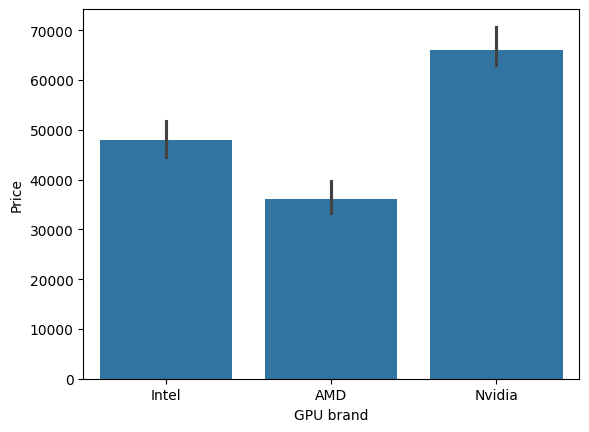

In [82]:
sns.barplot(x= df['GPU brand'] , y = df['Price'],estimator=np.median)


In [83]:
df.drop(columns=['Gpu'],inplace=True)

In [84]:
df.head()

,Company,TypeName,Ram,OpSys,Weight,Price,TouchScreen,IPS_Panel,ppi,Cpu_Name,HDD,SSD,Hybrid,Flash_Storage,GPU brand
0,Apple,Ultrabook,8,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,0,0,Intel
1,Apple,Ultrabook,8,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,0,128,Intel
2,HP,Notebook,8,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,0,0,Intel
3,Apple,Ultrabook,16,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,0,0,AMD
4,Apple,Ultrabook,8,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,0,0,Intel


In [85]:
                                                ##work with the  OpSys column 

In [86]:
df['OpSys'].value_counts()

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         26
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'macOS'),
  Text(1, 0, 'No OS'),
  Text(2, 0, 'Windows 10'),
  Text(3, 0, 'Mac OS X'),
  Text(4, 0, 'Linux'),
  Text(5, 0, 'Android'),
  Text(6, 0, 'Windows 10 S'),
  Text(7, 0, 'Chrome OS'),
  Text(8, 0, 'Windows 7')])

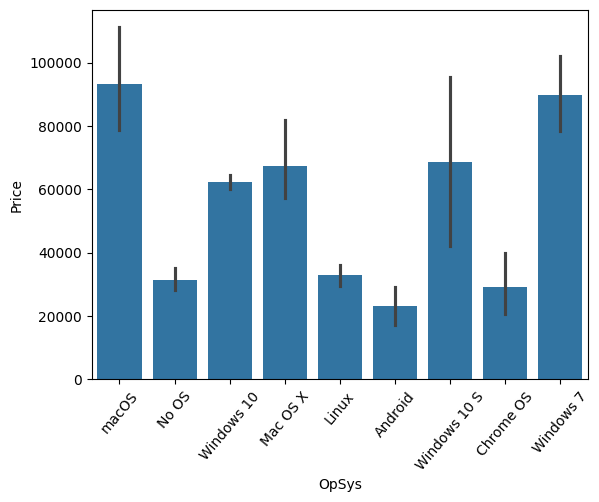

In [87]:
sns.barplot(x= df['OpSys'] , y = df['Price'])
plt.xticks(rotation = 50)

In [88]:
def cat_os(inp):
    if inp == 'Windows 10'or inp == 'Windows 7' or inp == 'Windows 10 S':
        return 'Windows'
    elif inp == 'macOS' or inp =='mac OS X':
        return 'mac'
    elif inp == 'Linux':
        return 'Linex'
    elif inp == 'Chrome OS':
        return "Chrome"
    else:
        return "Other OS"


In [89]:
df['OS']= df['OpSys'].apply(cat_os)

In [90]:
df.sample(6)

,Company,TypeName,Ram,OpSys,Weight,Price,TouchScreen,IPS_Panel,ppi,Cpu_Name,HDD,SSD,Hybrid,Flash_Storage,GPU brand,OS
533,Mediacom,Notebook,4,Windows 10,1.20,19660.32,0,1,165.632118,Intel Celeron Quad,0,32,0,0,Intel,Windows
526,Lenovo,Notebook,4,Windows 10,2.20,42570.72,0,0,141.211998,Intel Core i7,1000,0,0,0,Nvidia,Windows
186,Dell,Notebook,16,Windows 10,2.06,127712.16,1,0,138.461776,Intel Core i7,0,512,0,0,Nvidia,Windows
666,Dell,Notebook,8,Windows 10,2.06,50882.40,0,0,141.211998,Intel Core i5,1000,0,0,0,Intel,Windows
447,Dell,Workstation,8,Windows 10,2.23,106187.04,0,0,141.211998,Intel Xeon E3-1505M,1000,0,0,64,Nvidia,Windows
49,Asus,Notebook,4,Windows 10,2.80,24828.48,0,0,90.583402,Intel Pentium Quad,1000,0,0,0,Nvidia,Windows


In [91]:
df['OS'].value_counts()

OS
Windows     1125
Other OS      76
Linex         62
Chrome        26
mac           13
Name: count, dtype: int64

In [92]:
df.drop(columns=['OpSys'] , inplace=True)

<Axes: xlabel='OS', ylabel='Price'>

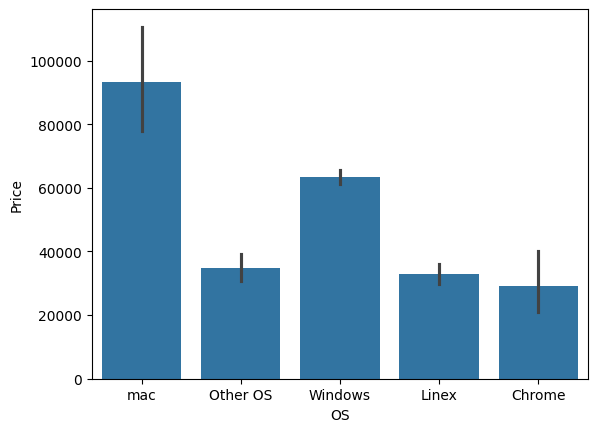

In [93]:
sns.barplot(x= df['OS'] , y = df['Price'])

In [94]:
df.head()

,Company,TypeName,Ram,Weight,Price,TouchScreen,IPS_Panel,ppi,Cpu_Name,HDD,SSD,Hybrid,Flash_Storage,GPU brand,OS
0,Apple,Ultrabook,8,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,0,0,Intel,mac
1,Apple,Ultrabook,8,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,0,128,Intel,mac
2,HP,Notebook,8,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,0,0,Intel,Other OS
3,Apple,Ultrabook,16,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,0,0,AMD,mac
4,Apple,Ultrabook,8,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,0,0,Intel,mac


In [95]:
                                                        ## work with the weight column

C:\Users\yashs\AppData\Local\Temp\ipykernel_5352\1125578356.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Weight'])


<Axes: xlabel='Weight', ylabel='Density'>

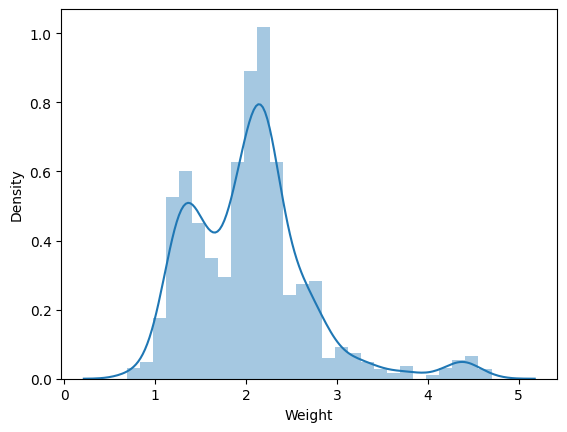

In [96]:
sns.distplot(df['Weight'])

<Axes: >

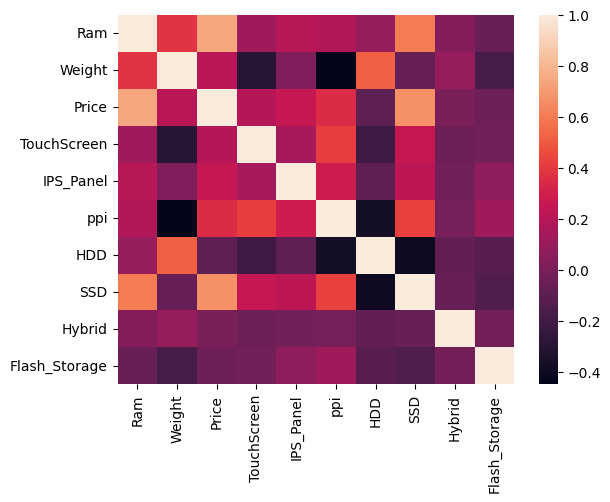

In [97]:
sns.heatmap(df.corr(numeric_only=True))

C:\Users\yashs\AppData\Local\Temp\ipykernel_5352\3556049916.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log(df['Price']))


<Axes: xlabel='Price', ylabel='Density'>

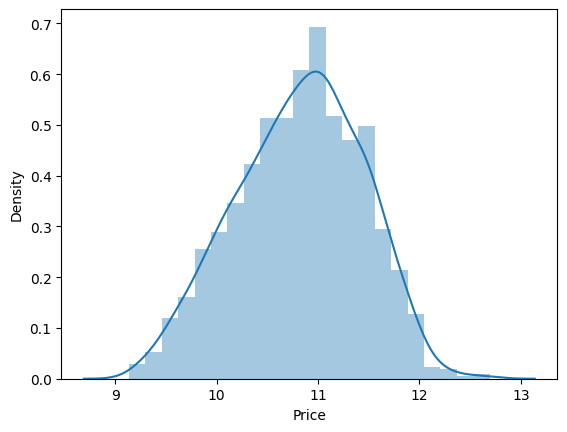

In [98]:
sns.distplot(np.log(df['Price']))

C:\Users\yashs\AppData\Local\Temp\ipykernel_5352\2275778512.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((df['Ram']))


<Axes: xlabel='Ram', ylabel='Density'>

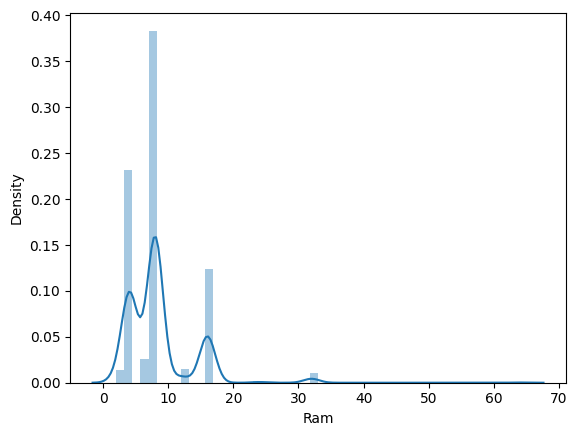

In [99]:
sns.distplot((df['Ram']))

In [100]:
df['Weight'].skew()

np.float64(1.145634503035145)

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1302 entries, 0 to 1302
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company        1302 non-null   object 
 1   TypeName       1302 non-null   object 
 2   Ram            1302 non-null   int64  
 3   Weight         1302 non-null   float64
 4   Price          1302 non-null   float64
 5   TouchScreen    1302 non-null   int64  
 6   IPS_Panel      1302 non-null   int64  
 7   ppi            1302 non-null   float64
 8   Cpu_Name       1302 non-null   object 
 9   HDD            1302 non-null   int64  
 10  SSD            1302 non-null   int64  
 11  Hybrid         1302 non-null   int64  
 12  Flash_Storage  1302 non-null   int64  
 13  GPU brand      1302 non-null   object 
 14  OS             1302 non-null   object 
dtypes: float64(3), int64(7), object(5)
memory usage: 162.8+ KB


Text(0.5, 1.0, 'weight  on QQ plot')

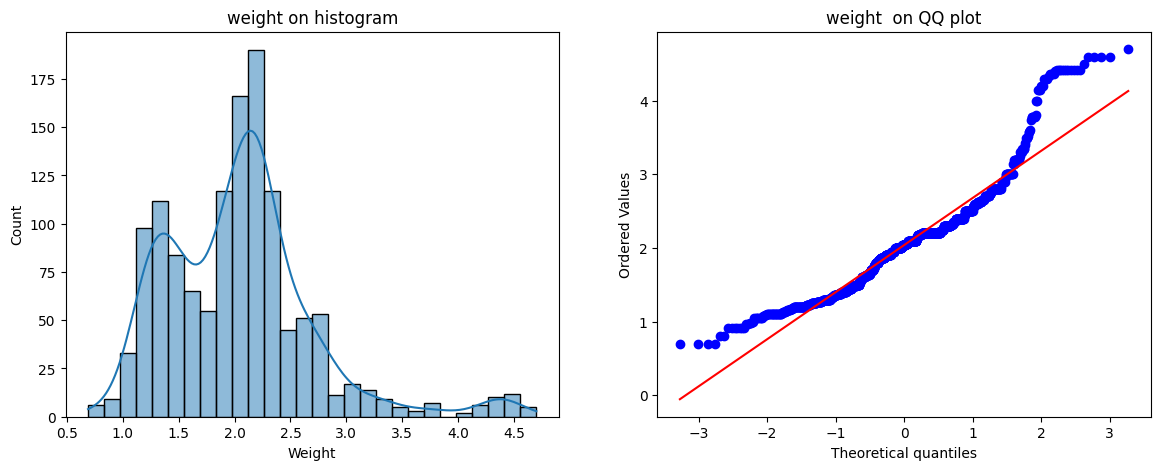

In [102]:
plt.figure(figsize=(14,5))
plt.subplot(121)
sns.histplot(df["Weight"] , kde=True)
plt.title("weight on histogram")

plt.subplot(122)
stats.probplot(df["Weight"]  , plot=plt)
plt.title("weight  on QQ plot" )

Text(0.5, 1.0, 'flash storage on QQ plot')

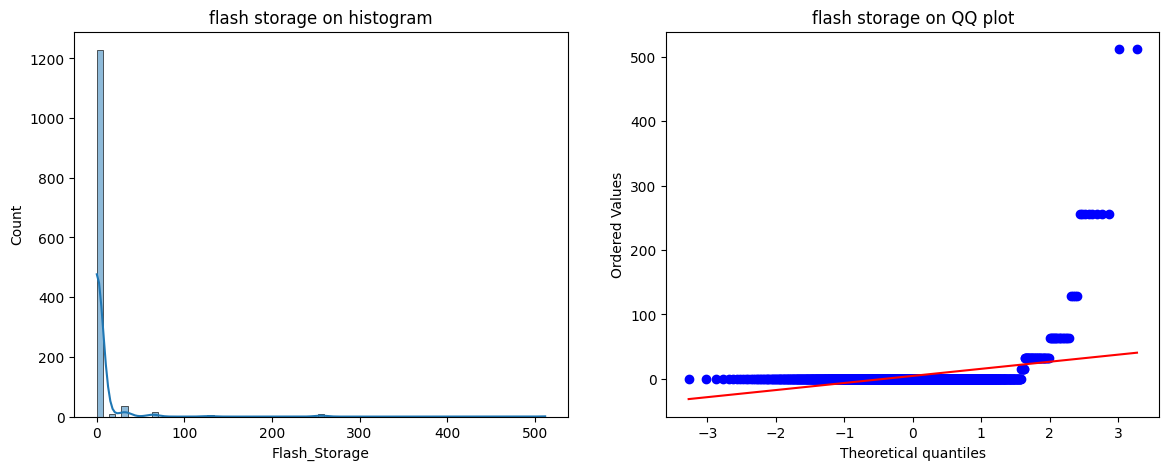

In [103]:
plt.figure(figsize=(14,5))
plt.subplot(121)
sns.histplot(df["Flash_Storage"] , kde=True)
plt.title("flash storage on histogram")

plt.subplot(122)
stats.probplot(df["Flash_Storage"]  , plot=plt)
plt.title("flash storage on QQ plot" )

In [104]:
df["Weight"].skew()

np.float64(1.145634503035145)

C:\Users\yashs\AppData\Local\Temp\ipykernel_5352\2814597050.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log(df["Weight"]))


<Axes: xlabel='Weight', ylabel='Density'>

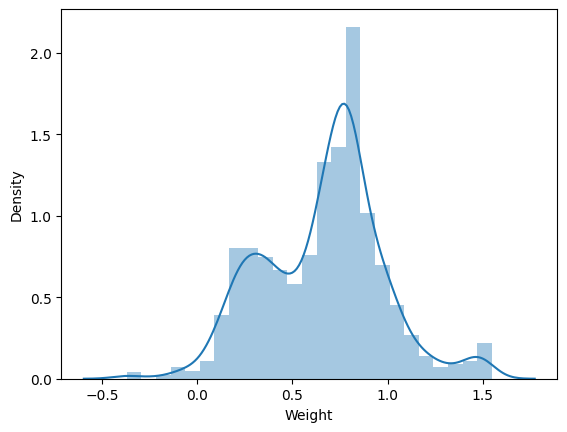

In [105]:
sns.distplot(np.log(df["Weight"]))

In [106]:
from sklearn.preprocessing import PowerTransformer 
from sklearn.preprocessing import FunctionTransformer

In [107]:
pt = PowerTransformer()
df['power_weight'] = pt.fit_transform(df[['Weight']])

In [108]:
ft = FunctionTransformer(func =np.log)
df['log_weight'] = ft.fit_transform(df['Weight'])

C:\Users\yashs\AppData\Local\Temp\ipykernel_5352\906449457.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['power_weight'])
C:\Users\yashs\AppData\Local\Temp\ipykernel_5352\906449457.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x = df['log_weight'])


Text(0.5, 1.0, 'log weight transformer ')

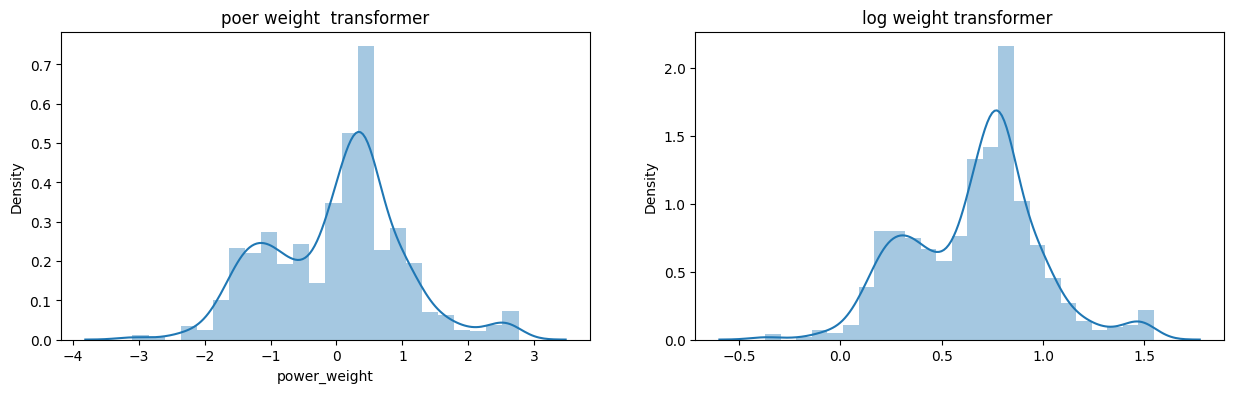

In [109]:
plt.figure(figsize=(15,4))
plt.subplot(121)
sns.distplot(df['power_weight'])
plt.title('poer weight  transformer')

plt.subplot(122)
sns.distplot(x = df['log_weight'])
plt.title('log weight transformer ')

Text(0.5, 1.0, 'log weight transformer ')

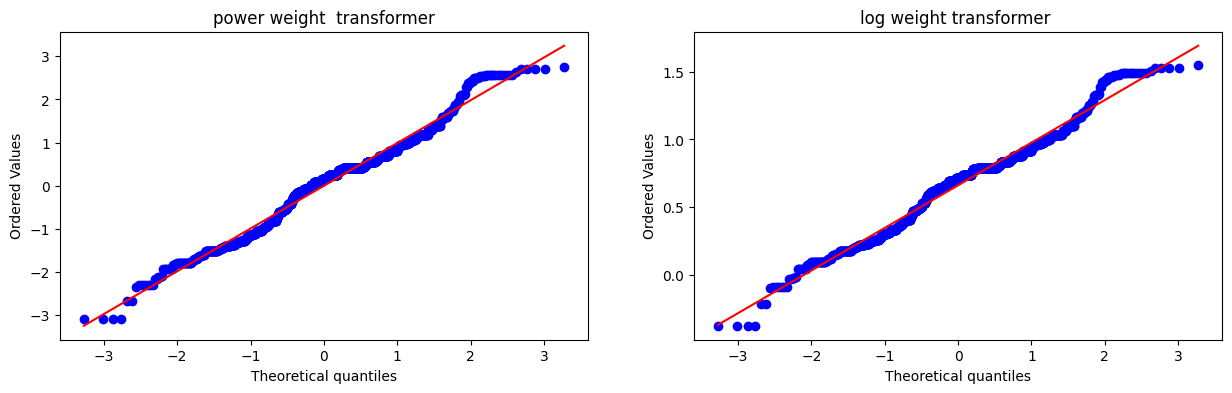

In [110]:
plt.figure(figsize=(15,4))
plt.subplot(121)
stats.probplot(df["power_weight"]  , plot=plt)
plt.title('power weight  transformer')

plt.subplot(122)
stats.probplot(df["log_weight"]  , plot=plt)
plt.title('log weight transformer ')

In [111]:
df['power_weight'].skew()

np.float64(-0.004059529657654764)

In [112]:
df['log_weight'].skew()

np.float64(-0.022303336509897555)

In [113]:
df['Weight'].skew()

np.float64(1.145634503035145)

In [114]:
df = df.drop(columns=['power_weight' , 'log_weight'])

In [115]:
df.isnull().sum()

Company          0
TypeName         0
Ram              0
Weight           0
Price            0
TouchScreen      0
IPS_Panel        0
ppi              0
Cpu_Name         0
HDD              0
SSD              0
Hybrid           0
Flash_Storage    0
GPU brand        0
OS               0
dtype: int64

In [116]:
                                                        ##save cleaned data

In [117]:
 df.to_csv("data/Cleaned_laptop_data.csv", index=False)

In [118]:
                                                    ## save data in pkl formate

In [119]:
import joblib
joblib.dump(df , "cleaned_laptop_data.pkl")

['cleaned_laptop_data.pkl']

In [120]:
                                                        ## split the data 

In [121]:
X = df.drop(columns=['Price'])
y = np.log(df['Price'])

In [122]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.15,random_state=2)

In [123]:
X_train.head()

,Company,TypeName,Ram,Weight,TouchScreen,IPS_Panel,ppi,Cpu_Name,HDD,SSD,Hybrid,Flash_Storage,GPU brand,OS
183,Toshiba,Notebook,8,2.00,0,0,100.454670,Intel Core i5,0,128,0,0,Intel,Windows
1141,MSI,Gaming,8,2.40,0,0,141.211998,Intel Core i7,1000,128,0,0,Nvidia,Windows
1049,Asus,Netbook,4,1.20,0,0,135.094211,Intel Celeron Dual,0,0,0,16,Intel,Chrome
1020,Dell,2 in 1 Convertible,4,2.08,1,1,141.211998,Intel Core i3,1000,0,0,0,Intel,Windows
878,Dell,Notebook,4,2.18,0,0,141.211998,Intel Core i5,1000,128,0,0,Nvidia,Windows


In [124]:
y_train.head()

183     10.651384
1141    11.016798
1049     9.638174
1020    10.655148
878     10.791749
Name: Price, dtype: float64

In [125]:
X_train.describe()

,Ram,Weight,TouchScreen,IPS_Panel,ppi,HDD,SSD,Hybrid,Flash_Storage
count,1106.000000,1106.000000,1106.000000,1106.000000,1106.000000,1106.000000,1106.000000,1106.000000,1106.000000
mean,8.477396,2.035050,0.147378,0.276673,142.262601,405.660036,186.180832,10.405063,4.585895
std,5.198323,0.673412,0.354643,0.447556,33.704759,516.044805,188.396587,100.398854,30.805364
min,2.000000,0.690000,0.000000,0.000000,90.583402,0.000000,0.000000,0.000000,0.000000
25%,4.000000,1.500000,0.000000,0.000000,127.335675,0.000000,0.000000,0.000000,0.000000
50%,8.000000,2.040000,0.000000,0.000000,141.211998,0.000000,256.000000,0.000000,0.000000
75%,8.000000,2.300000,0.000000,1.000000,157.350512,1000.000000,256.000000,0.000000,0.000000
max,64.000000,4.700000,1.000000,1.000000,276.053530,2000.000000,1024.000000,1000.000000,512.000000


In [130]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error , mean_absolute_error
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor,ExtraTreesRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [203]:
ohe_col = ['Company' , 'TypeName' , 'Cpu_Name' , 'GPU brand' , 'OS']
scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler()
}

for name, scaler in scalers.items():

    step2 = ColumnTransformer(
        transformers=[
            ('ohe', OneHotEncoder(
                handle_unknown='ignore',
                drop='first'
            ), ohe_col)
        ],
        remainder=scaler
    )

    pipeline = Pipeline([
        ("preprocessor", step2),
        ("model", LinearRegression())
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    print(name)
    print("R2 Score:", r2_score(y_test, y_pred))
    print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
    print()

D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


StandardScaler
R2 Score: 0.8410809523451337
RMSE: 0.24656573084217573

MinMaxScaler
R2 Score: 0.8410811899608925
RMSE: 0.24656554650956738

RobustScaler
R2 Score: 0.8413339127886486
RMSE: 0.2463694163747276



## linear regression 

In [206]:
ohe_col = ['Company' , 'TypeName' , 'Cpu_Name' , 'GPU brand' , 'OS']
num_col = ['Ram','Weight','ppi' ,'HDD','SSD' ,'Hybrid' ,'Flash_Storage']
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(handle_unknown='ignore',drop='first'),ohe_col),
    ('scaler' , RobustScaler(),num_col)
],remainder='passthrough')

step2 = LinearRegression()

linear_pipe = Pipeline([
    ('step1' , step1),
    ('step2' , step2)
])
#cross validation 
rmse_score= -cross_val_score(
    linear_pipe , 
    X_train, 
    y_train,
    cv = 10,
    scoring='neg_root_mean_squared_error'
)

linear_pipe.fit(X_train , y_train)

y_pred= linear_pipe.predict(X_test)

print('r2 score' , r2_score(y_test , y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
print("Mean RMSE:", rmse_score.mean())
print("Std RMSE:", rmse_score.std())


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

r2 score 0.8413412826411725
MAE 0.1942799562352748
Mean RMSE: 0.24795868180956981
Std RMSE: 0.020198234731582897


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## Ridge regression 

In [207]:
ohe_col = ['Company', 'TypeName', 'Cpu_Name', 'GPU brand', 'OS']
num_col = ['Ram','Weight','ppi' ,'HDD','SSD' ,'Hybrid' ,'Flash_Storage']
step1 = ColumnTransformer(
    transformers=[
        ('col_tnf',
         OneHotEncoder(handle_unknown='ignore', drop='first'),
         ohe_col),
         ('scaler' , RobustScaler(),num_col)
    ],
    remainder='passthrough'
)

alphas = [1, 2, 4, 6, 8, 10, 12, 15, 20]

results = []

for alpha in alphas:

    step2 = Ridge(alpha=alpha)

    ridge_pipe = Pipeline([
        ('step1', step1),
        ('step2', step2)
    ])

    # Cross Validation
    rmse_score = -cross_val_score(
        ridge_pipe,
        X_train,
        y_train,
        cv=10,
        scoring='neg_root_mean_squared_error'
    )

    mean_rmse = rmse_score.mean()
    std_rmse = rmse_score.std()

    results.append([
        alpha,
        mean_rmse,
        std_rmse
    ])

    print(f"Alpha: {alpha}")
    print(f"Mean RMSE: {mean_rmse}")
    print(f"Std RMSE: {std_rmse}")
    print("-" * 30)

D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

Alpha: 1
Mean RMSE: 0.24948826006711428
Std RMSE: 0.01886612131591896
------------------------------


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

Alpha: 2
Mean RMSE: 0.25173117718924154
Std RMSE: 0.018813982529303035
------------------------------


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

...

D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

Alpha: 15
Mean RMSE: 0.2644716835220978
Std RMSE: 0.02188098472204382
------------------------------


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

Alpha: 20
Mean RMSE: 0.26763511107648696
Std RMSE: 0.02251955941208488
------------------------------


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [208]:
results_df = pd.DataFrame(
    results,
    columns=['Alpha', 'Mean RMSE', 'Std RMSE']
)

print(results_df)

   Alpha  Mean RMSE  Std RMSE
0      1   0.249488  0.018866
1      2   0.251731  0.018814
2      4   0.254891  0.019397
3      6   0.257209  0.020015
4      8   0.259140  0.020549
5     10   0.260822  0.020998
6     12   0.262355  0.021395
7     15   0.264472  0.021881
8     20   0.267635  0.022520


In [209]:
best_alpha = results_df.loc[
    results_df['Mean RMSE'].idxmin(),
    'Alpha'
]
print("Best Alpha:", best_alpha)

Best Alpha: 1


In [160]:
# alpha = 1 ke liye best results hai 

In [210]:
ohe_col = ['Company' , 'TypeName' , 'Cpu_Name' , 'GPU brand' , 'OS']
num_col = ['Ram','Weight','ppi' ,'HDD','SSD' ,'Hybrid' ,'Flash_Storage']
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(handle_unknown='ignore',drop='first'),ohe_col),
     ('scaler' , RobustScaler(),num_col)
],remainder='passthrough')


step2 = Ridge(alpha=2)

ridge_pipe = Pipeline([
    ('step1' , step1),
    ('step2' , step2)
])
#cross validation 
rmse_score= -cross_val_score(
    ridge_pipe , 
    X_train, 
    y_train,
    cv = 10,
    scoring='neg_root_mean_squared_error'
)

ridge_pipe.fit(X_train , y_train)

y_pred= ridge_pipe.predict(X_test)

print('r2 score' , r2_score(y_test , y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
print("Mean RMSE:", rmse_score.mean())
print("Std RMSE:", rmse_score.std())


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

r2 score 0.8402367329369662
MAE 0.19530997223695049
Mean RMSE: 0.25173117718924154
Std RMSE: 0.018813982529303035


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## lasso regression

In [211]:
ohe_col = ['Company', 'TypeName', 'Cpu_Name', 'GPU brand', 'OS']
num_col = ['Ram','Weight','ppi' ,'HDD','SSD' ,'Hybrid' ,'Flash_Storage']
step1 = ColumnTransformer(
    transformers=[
        ('col_tnf',
         OneHotEncoder(handle_unknown='ignore', drop='first'),
         ohe_col),
         ('scaler' , RobustScaler(),num_col)
    ],
    remainder='passthrough'
)

alphas = [1, 2, 4, 6, 8, 10, 12, 15, 20]

results = []

for alpha in alphas:

    step2 = Lasso(alpha=alpha)

    lasso_pipe = Pipeline([
        ('step1', step1),
        ('step2', step2)
    ])

    # Cross Validation
    rmse_score = -cross_val_score(
        lasso_pipe,
        X_train,
        y_train,
        cv=10,
        scoring='neg_root_mean_squared_error'
    )

    mean_rmse = rmse_score.mean()
    std_rmse = rmse_score.std()

    results.append([
        alpha,
        mean_rmse,
        std_rmse
    ])

    print(f"Alpha: {alpha}")
    print(f"Mean RMSE: {mean_rmse}")
    print(f"Std RMSE: {std_rmse}")
    print("-" * 30)

results_df = pd.DataFrame(
    results,
    columns=['Alpha', 'Mean RMSE', 'Std RMSE']
)

print(results_df)

best_alpha = results_df.loc[
    results_df['Mean RMSE'].idxmin(),
    'Alpha'
]

print("Best Alpha:", best_alpha)

D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

Alpha: 1
Mean RMSE: 0.623639111679878
Std RMSE: 0.043302917368282505
------------------------------


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

Alpha: 2
Mean RMSE: 0.6236464019666166
Std RMSE: 0.04348576304853336
------------------------------


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

...

D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

Alpha: 15
Mean RMSE: 0.6236464019666166
Std RMSE: 0.04348576304853336
------------------------------


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

Alpha: 20
Mean RMSE: 0.6236464019666166
Std RMSE: 0.04348576304853336
------------------------------
   Alpha  Mean RMSE  Std RMSE
0      1   0.623639  0.043303
1      2   0.623646  0.043486
2      4   0.623646  0.043486
3      6   0.623646  0.043486
4      8   0.623646  0.043486
5     10   0.623646  0.043486
6     12   0.623646  0.043486
7     15   0.623646  0.043486
8     20   0.623646  0.043486
Best Alpha: 1


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [213]:
ohe_col = ['Company' , 'TypeName' , 'Cpu_Name' , 'GPU brand' , 'OS']
num_col = ['Ram','Weight','ppi' ,'HDD','SSD' ,'Hybrid' ,'Flash_Storage']
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(handle_unknown='ignore',drop='first'),ohe_col),
    
],remainder='passthrough')


step2 = Lasso(alpha=1)

lasso_pipe = Pipeline([
    ('step1' , step1),
    ('step2' , step2)
])
#cross validation 
rmse_score= -cross_val_score(
    lasso_pipe , 
    X_train, 
    y_train,
    cv = 10,
    scoring='neg_root_mean_squared_error'
)

lasso_pipe.fit(X_train , y_train)

y_pred= lasso_pipe.predict(X_test)

print('r2 score' , r2_score(y_test , y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
print("Mean RMSE:", rmse_score.mean())
print("Std RMSE:", rmse_score.std())


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

r2 score 0.5139629241983661
MAE 0.33699484786368167
Mean RMSE: 0.4333023560972823
Std RMSE: 0.0338710427837012


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## knn

In [214]:
ohe_col = ['Company' , 'TypeName' , 'Cpu_Name' , 'GPU brand' , 'OS']
num_col = ['Ram','Weight','ppi' ,'HDD','SSD' ,'Hybrid' ,'Flash_Storage']
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(handle_unknown='ignore',drop='first'),ohe_col),
     ('scaler' , RobustScaler(),num_col)
],remainder='passthrough')
i = [1,2,3,4,5,6,8 ,9,10,15]
for x in i :
    step2 = KNeighborsRegressor(n_neighbors=x )

    knn_pipe = Pipeline([
        ('step1' , step1),
        ('step2' , step2)
    ])
    #cross validation 
    rmse_score= -cross_val_score(
        knn_pipe , 
        X_train, 
        y_train,
        cv = 10,
        scoring='neg_root_mean_squared_error'
    )

    knn_pipe.fit(X_train , y_train)

    y_pred= knn_pipe.predict(X_test)
    print("x :", x)
    print('r2 score' , r2_score(y_test , y_pred))
    print('MAE',mean_absolute_error(y_test,y_pred))
    print("Mean RMSE:", rmse_score.mean())
    print("Std RMSE:", rmse_score.std())


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

x : 1
r2 score 0.800411477293386
MAE 0.19745597229568332
Mean RMSE: 0.27919285381737985
Std RMSE: 0.02721271050535146


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

x : 2
r2 score 0.8258022946405067
MAE 0.18793617431860446
Mean RMSE: 0.2595765546491461
Std RMSE: 0.022042755177270935


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

...

x : 9
r2 score 0.8202052222738906
MAE 0.19702113478626293
Mean RMSE: 0.2703063702168447
Std RMSE: 0.024523879135746687


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

x : 10
r2 score 0.8185678679364883
MAE 0.20024297392342683
Mean RMSE: 0.27093998502425837
Std RMSE: 0.022980484207184064


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

x : 15
r2 score 0.794624831678155
MAE 0.2102928741209047
Mean RMSE: 0.2768972714682566
Std RMSE: 0.022184913146112175


In [189]:
# n_neighbors = 6 knn nke liye best hai 

In [215]:
ohe_col = ['Company' , 'TypeName' , 'Cpu_Name' , 'GPU brand' , 'OS']
num_col = ['Ram','Weight','ppi' ,'HDD','SSD' ,'Hybrid' ,'Flash_Storage']
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(handle_unknown='ignore',drop='first'),ohe_col),
     ('scaler' , RobustScaler(),num_col)
],remainder='passthrough')

step2 = KNeighborsRegressor(n_neighbors=6 )

knn_pipe = Pipeline([
    ('step1' , step1),
    ('step2' , step2)
])
    #cross validation 
rmse_score= -cross_val_score(
    knn_pipe , 
    X_train, 
    y_train,
    cv = 10,
    scoring='neg_root_mean_squared_error'
)

knn_pipe.fit(X_train , y_train)

y_pred= knn_pipe.predict(X_test)
print('r2 score' , r2_score(y_test , y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
print("Mean RMSE:", rmse_score.mean())
print("Std RMSE:", rmse_score.std())


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

r2 score 0.8291596292798561
MAE 0.19096091474558474
Mean RMSE: 0.2643247534774199
Std RMSE: 0.022063778209277542


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## decision tree regression

In [191]:
ohe_col = ['Company' , 'TypeName' , 'Cpu_Name' , 'GPU brand' , 'OS']
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(handle_unknown='ignore',drop='first'),ohe_col)
],remainder='passthrough')

depth = [1,4,7,10,15,20,25,30]

for i in depth:
    step2 = DecisionTreeRegressor(random_state=42 , max_depth=i)

    decision_pipe = Pipeline([
        ('step1' , step1),
        ('step2' , step2)
    ])
#cross validation 
    rmse_score= -cross_val_score(
        decision_pipe , 
        X_train, 
        y_train,
        cv = 10,
        scoring='neg_root_mean_squared_error'
    )

    decision_pipe.fit(X_train , y_train)

    y_pred= decision_pipe.predict(X_test)
    print('depth :' , i)
    print('r2 score' , r2_score(y_test , y_pred))
    print('MAE',mean_absolute_error(y_test,y_pred))
    print("Mean RMSE:", rmse_score.mean())
    print("Std RMSE:", rmse_score.std())


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

depth : 1
r2 score 0.5457483716872795
MAE 0.33617273228597094
Mean RMSE: 0.45626623096554475
Std RMSE: 0.024334897192889456


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

depth : 4
r2 score 0.7828549490785297
MAE 0.22458151629025297
Mean RMSE: 0.30839756028181925
Std RMSE: 0.022430258583809776


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

...

D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

depth : 25
r2 score 0.8101236584286312
MAE 0.19690456737581458
Mean RMSE: 0.2899347294860248
Std RMSE: 0.02931466482875573


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

depth : 30
r2 score 0.823695936769501
MAE 0.19066623662148047
Mean RMSE: 0.28640439985846167
Std RMSE: 0.02929679367630055


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
# depth = 10 ke liye decision tree best hai 

In [192]:
ohe_col = ['Company' , 'TypeName' , 'Cpu_Name' , 'GPU brand' , 'OS']
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(handle_unknown='ignore',drop='first'),ohe_col)
],remainder='passthrough')

step2 = DecisionTreeRegressor(random_state=42 , max_depth=10)

decision_pipe = Pipeline([
    ('step1' , step1),
    ('step2' , step2)
])
#cross validation 
rmse_score= -cross_val_score(
    decision_pipe , 
    X_train, 
    y_train,
    cv = 10,
    scoring='neg_root_mean_squared_error'
)

decision_pipe.fit(X_train , y_train)

y_pred= decision_pipe.predict(X_test)
print('depth :' , i)
print('r2 score' , r2_score(y_test , y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
print("Mean RMSE:", rmse_score.mean())
print("Std RMSE:", rmse_score.std())


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

depth : 30
r2 score 0.8487602619679077
MAE 0.17513953787112607
Mean RMSE: 0.2725314587310703
Std RMSE: 0.027459035876072135


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## Random forest regression

In [194]:
ohe_col = ['Company' , 'TypeName' , 'Cpu_Name' , 'GPU brand' , 'OS']
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(handle_unknown='ignore',drop='first'),ohe_col)
],remainder='passthrough')

step2 = RandomForestRegressor(n_estimators=100,
                              random_state=3,
                              max_samples=0.5,
                              max_features=0.75,
                              max_depth=None)

random_pipe = Pipeline([
    ('step1' , step1),
    ('step2' , step2)
])
#cross validation 
rmse_score= -cross_val_score(
    random_pipe , 
    X_train, 
    y_train,
    cv = 10,
    scoring='neg_root_mean_squared_error'
)

random_pipe.fit(X_train , y_train)

y_pred= random_pipe.predict(X_test)

print('r2 score' , r2_score(y_test , y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
print("Mean RMSE:", rmse_score.mean())
print("Std RMSE:", rmse_score.std())


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

r2 score 0.8867694408580367
MAE 0.1609530064216358
Mean RMSE: 0.21916074046454734
Std RMSE: 0.013233980562552254


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## gradientboosting

In [195]:
ohe_col = ['Company' , 'TypeName' , 'Cpu_Name' , 'GPU brand' , 'OS']
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(handle_unknown='ignore',drop='first'),ohe_col)
],remainder='passthrough')

step2 = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=None
                                 )

gradient_pipe = Pipeline([
    ('step1' , step1),
    ('step2' , step2)
])
#cross validation 
rmse_score= -cross_val_score(
    gradient_pipe , 
    X_train, 
    y_train,
    cv = 10,
    scoring='neg_root_mean_squared_error'
)

gradient_pipe.fit(X_train , y_train)

y_pred= gradient_pipe.predict(X_test)

print('r2 score' , r2_score(y_test , y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
print("Mean RMSE:", rmse_score.mean())
print("Std RMSE:", rmse_score.std())


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

r2 score 0.8196672461258214
MAE 0.1919207076391148
Mean RMSE: 0.28311812532865643
Std RMSE: 0.029575658103410153


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## adaboost regression

In [196]:
ohe_col = ['Company' , 'TypeName' , 'Cpu_Name' , 'GPU brand' , 'OS']
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(handle_unknown='ignore',drop='first'),ohe_col)
],remainder='passthrough')

step2 = AdaBoostRegressor(n_estimators=15,learning_rate=1.0)

adabooste_pipe = Pipeline([
    ('step1' , step1),
    ('step2' , step2)
])
#cross validation 
rmse_score= -cross_val_score(
    adabooste_pipe , 
    X_train, 
    y_train,
    cv = 10,
    scoring='neg_root_mean_squared_error'
)

adabooste_pipe.fit(X_train , y_train)

y_pred= adabooste_pipe.predict(X_test)

print('r2 score' , r2_score(y_test , y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
print("Mean RMSE:", rmse_score.mean())
print("Std RMSE:", rmse_score.std())


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

r2 score 0.7711165150524952
MAE 0.23602363172913352
Mean RMSE: 0.2934590411093658
Std RMSE: 0.02560204272606039


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## Extra tree regression

In [197]:
ohe_col = ['Company' , 'TypeName' , 'Cpu_Name' , 'GPU brand' , 'OS']
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(handle_unknown='ignore',drop='first'),ohe_col)
],remainder='passthrough')

step2 = ExtraTreesRegressor(
        n_estimators=100,
        random_state=42

)

extra_tree_pipe = Pipeline([
    ('step1' , step1),
    ('step2' , step2)
])
#cross validation 
rmse_score= -cross_val_score(
    extra_tree_pipe , 
    X_train, 
    y_train,
    cv = 10,
    scoring='neg_root_mean_squared_error'
)

extra_tree_pipe.fit(X_train , y_train)

y_pred= extra_tree_pipe.predict(X_test)

print('r2 score' , r2_score(y_test , y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
print("Mean RMSE:", rmse_score.mean())
print("Std RMSE:", rmse_score.std())


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

r2 score 0.8655170311103888
MAE 0.16328602558486227
Mean RMSE: 0.23948226567677575
Std RMSE: 0.018765081240452203


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## svr

In [216]:
ohe_col = ['Company' , 'TypeName' , 'Cpu_Name' , 'GPU brand' , 'OS']
num_col = ['Ram','Weight','ppi' ,'HDD','SSD' ,'Hybrid' ,'Flash_Storage']
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(handle_unknown='ignore',drop='first'),ohe_col),
     ('scaler' , RobustScaler(),num_col)
],remainder='passthrough')

step2 = SVR()

svr_pipe = Pipeline([
    ('step1' , step1),
    ('step2' , step2)
])
#cross validation 
rmse_score= -cross_val_score(
    svr_pipe , 
    X_train, 
    y_train,
    cv = 10,
    scoring='neg_root_mean_squared_error'
)

svr_pipe.fit(X_train , y_train)

y_pred= svr_pipe.predict(X_test)

print('r2 score' , r2_score(y_test , y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
print("Mean RMSE:", rmse_score.mean())
print("Std RMSE:", rmse_score.std())


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

r2 score 0.46773434990036145
MAE 0.3569528998178394
Mean RMSE: 0.43474677094267034
Std RMSE: 0.036990071523687086


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## XGBR regression

In [199]:
ohe_col = ['Company' , 'TypeName' , 'Cpu_Name' , 'GPU brand' , 'OS']
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(handle_unknown='ignore',drop='first'),ohe_col)
],remainder='passthrough')

step2 = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
)

xgbr_pipe = Pipeline([
    ('step1' , step1),
    ('step2' , step2)
])
#cross validation 
rmse_score= -cross_val_score(
    xgbr_pipe , 
    X_train, 
    y_train,
    cv = 10,
    scoring='neg_root_mean_squared_error'
)

xgbr_pipe.fit(X_train , y_train)

y_pred= xgbr_pipe.predict(X_test)

print('r2 score' , r2_score(y_test , y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
print("Mean RMSE:", rmse_score.mean())
print("Std RMSE:", rmse_score.std())


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unkno

r2 score 0.8960858573781254
MAE 0.1520259713469521
Mean RMSE: 0.21882608804815024
Std RMSE: 0.015207154563020717


D:\anaconda\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [200]:
from sklearn import set_config

set_config(display="diagram")

xgbr_pipe

,steps,"[('step1', ...), ('step2', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('col_tnf', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [201]:
import joblib


In [202]:
joblib.dump(xgbr_pipe , "laptop_model.pkl")

['laptop_model.pkl']

In [219]:
joblib.dump(df, "laptop_cleaned_data.pkl")

['laptop_cleaned_data.pkl']

In [222]:
model = joblib.load("data/laptop_model.pkl")
print(type(model))

<class 'sklearn.pipeline.Pipeline'>


In [235]:
new_data = pd.DataFrame(
    [['HP'	,'Notebook','8',	'1.86',	'0',	'0',	'141.21199808219862',	'Intel Core i5',	'0',	'256',	'0','0','Intel','Other OS']],
    columns=['Company',	'TypeName',	'Ram',	'Weight',	'TouchScreen',	'IPS_Panel',	'ppi',	'Cpu_Name',	'HDD',	'SSD',	'Hybrid',	'Flash_Storage',	'GPU brand',	'OS']
)

prediction = np.exp(xgbr_pipe.predict(new_data))

print(prediction)

[32703.393]


In [236]:
X_train.head(10)

,Company,TypeName,Ram,Weight,TouchScreen,IPS_Panel,ppi,Cpu_Name,HDD,SSD,Hybrid,Flash_Storage,GPU brand,OS
183,Toshiba,Notebook,8,2.00,0,0,100.454670,Intel Core i5,0,128,0,0,Intel,Windows
1141,MSI,Gaming,8,2.40,0,0,141.211998,Intel Core i7,1000,128,0,0,Nvidia,Windows
1049,Asus,Netbook,4,1.20,0,0,135.094211,Intel Celeron Dual,0,0,0,16,Intel,Chrome
1020,Dell,2 in 1 Convertible,4,2.08,1,1,141.211998,Intel Core i3,1000,0,0,0,Intel,Windows
878,Dell,Notebook,4,2.18,0,0,141.211998,Intel Core i5,1000,128,0,0,Nvidia,Windows
1066,Asus,Gaming,64,3.58,0,1,127.335675,Intel Core i7,0,1000,0,0,Nvidia,Windows
315,Dell,Notebook,8,2.33,0,0,141.211998,Intel Core i5,1000,128,0,0,AMD,Windows
1003,HP,Notebook,4,1.64,0,0,111.935204,Intel Core i5,500,0,0,0,Intel,Windows
119,Asus,Notebook,8,1.70,0,0,141.211998,Intel Core i7,0,256,0,0,Nvidia,Windows
367,Lenovo,Gaming,8,2.40,0,1,141.211998,Intel Core i5,1000,128,0,0,Nvidia,Other OS


In [231]:
X_train['GPU brand'].unique()

array(['Intel', 'Nvidia', 'AMD'], dtype=object)

In [232]:
X_train['Hybrid'].unique()

array([   0, 1000,  508])

In [233]:
X_train['Flash_Storage'].unique()

array([  0,  16,  32,  64, 256, 128, 512])